# Chapter 21: Markets, Teams, and Institutions

A team adds a shortcut between two workflow stages. Every participant sees a privately attractive route, yet their collective routing can increase delay. The missing ingredient is congestion: each choice changes the cost other participants face.

This notebook solves a symmetric continuous-flow Braess construction. Two outer routes share a new shortcut route, with linear congestion and fixed delays. It calculates private equilibrium and total social travel time, then compares a toll intervention and an exact social optimum. The example is a declared institution model. It does not estimate a real market or suggest that every new workflow interface causes a paradox.

**Outcome:** Compare Braess equilibrium, social optimum, tolls, and overhead.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let total demand be D. Symmetry assigns x to each outer route and z to the shortcut, so 2x+z=D. Each congestible edge carries x+z and takes time v=(x+z)/capacity. Outer path time is v+c; shortcut time is 2v+overhead. The shortcut also pays a private toll.

At an interior equilibrium, used routes have equal private cost. Solving v+c=2v+overhead+toll gives z=2 capacity(c-overhead-toll)-D, clipped to [0,D]. Boundary clipping handles unused outer or shortcut routes. Without the shortcut, outer flow is D/2 and total travel time is D[D/(2 capacity)+c].

Social travel time excludes toll transfers and equals 2x(v+c)+z(2v+overhead). After substitution it is (D+z)^2/(2 capacity)+c(D-z)+overhead*z. This convex quadratic is minimized at z=capacity(c-overhead)-D, clipped to [0,D]. The price of anarchy compares equilibrium social time with that minimum, not with toll-inclusive private expense.

## Apply this to an agent

Adding a route or worker can change the incentives of every participant. Compare private routing choices with total workflow cost before assuming that another available path improves the agent team. The network is a declared construction, not a measured deployment.

## A calculation you can run

Declare demand, congestion capacity, outer constant delay, shortcut overhead, and toll. Validation requires positive demand and capacity and nonnegative other quantities. The function computes symmetric equilibrium flow, path costs, total delay, optimal shortcut flow, and toll revenue.

The figure varies shortcut flow from zero to total demand and plots exact social travel time. Its minimum should match the reported optimum. In the changed case add toll 0.5 without changing physical travel times. Predict how it shifts equilibrium, then compare social cost. The transfer case reduces demand, checking that a shortcut need not worsen performance under every loading condition.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 21
inputs = {'demand': 1,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed teaching example

Calculated quantities:
{
  "without_shortcut_total_time": 1.5,
  "equilibrium_shortcut_flow": 1.0,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 2.0,
  "equilibrium_private_outer_time": 2.0,
  "equilibrium_private_shortcut_time": 2.0,
  "optimal_shortcut_flow": 0,
  "optimal_social_time": 1.5,
  "price_of_anarchy": 1.333333333,
  "braess_worsens": true,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need 

Without the shortcut, default total time is 1(0.5+1)=1.5. With a zero-cost shortcut, equilibrium sends all demand through it, giving path time 2 and total time 2. The social optimum uses no shortcut and remains at 1.5. Price of anarchy is 2/1.5=4/3.

A toll 0.5 changes the equilibrium shortcut flow to zero. Outer private time is 1.5, while an unused shortcut would also cost 1.5 including toll. Total travel time returns to 1.5. The toll affects incentives; it is not counted as destroyed travel time or an extra physical delay.

The toll 0.5 sits exactly at the break-even value, so this teaching case is knife-edge. At toll 0.49 the lab returns shortcut flow 0.02 and equilibrium social time 1.5002, and at 0.51 it returns flow 0 and time 1.5. Try nearby tolls to see the threshold rather than reading 0.5 as a robust remedy.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


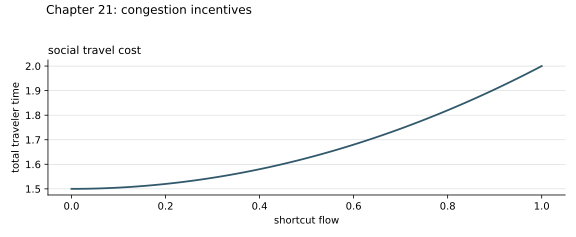

In [3]:
display(SVG(figure_svg(report)))

**Figure 21.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The paradox relies on a particular network and demand regime. At low demand, the shortcut can be socially useful and privately efficient. Presenting the default construction as a law against connectivity would erase those conditions.

Institutional metrics can also confuse transfers with resource costs. A toll payment changes who bears money but is excluded from this travel-time objective. A real institution may care about distributional effects or administrative overhead, which should be modeled separately. Shortcut overhead here is a real delay and therefore enters social cost.

Continuous equilibrium assumes many small participants choosing minimum private cost. A small team with indivisible jobs, strategic coordination, or centralized routing may behave differently. The calculation is an exact finite model result under those assumptions, not a fitted causal claim about organizational performance.

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "without_shortcut_total_time": 1.5,
  "equilibrium_shortcut_flow": 0,
  "equilibrium_outer_flow_each": 0.5,
  "equilibrium_social_time": 1.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.5,
  "optimal_shortcut_flow": 0,
  "optimal_social_time": 1.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need

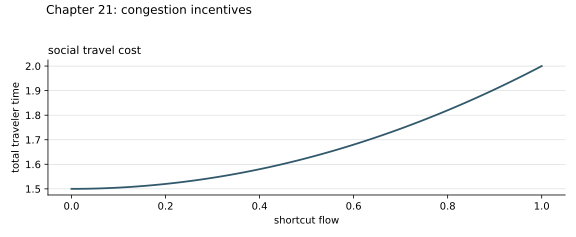

In [4]:
changed_inputs = {'demand': 1,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0.5}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 21.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

At demand 0.5, capacity 1, and constant delay 1, equilibrium sends all flow through the shortcut. Its total time is 0.5, below the no-shortcut total 0.625. The social optimum also uses shortcut flow 0.5, so price of anarchy is 1.

For workflow analysis, identify who selects routes and which costs they internalize. Separate routing overhead from incentive charges and preserve demand units. Compare local choice with a collective objective before adding a new interface. If route delays are estimated, collect measurements under several loads rather than assuming a linear congestion law.

In [5]:
transfer_inputs = {'demand': 0.5,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed transfer example

Calculated quantities:
{
  "without_shortcut_total_time": 0.625,
  "equilibrium_shortcut_flow": 0.5,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 0.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.0,
  "optimal_shortcut_flow": 0.5,
  "optimal_social_time": 0.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need add

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **demand:** Positive continuous traveler or job flow in normalized units.
- **capacity:** Positive flow scale of each linear congestible edge.
- **constant_time:** Nonnegative fixed delay of each outer constant edge.
- **shortcut_overhead:** Nonnegative real delay on the shortcut.
- **shortcut_toll:** Nonnegative private incentive charge, excluded from travel-time social cost.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch21.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "without_shortcut_total_time": 0.625,
  "equilibrium_shortcut_flow": 0.5,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 0.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.0,
  "optimal_shortcut_flow": 0.5,
  "optimal_social_time": 0.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and h

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c21-d01"></a>

### Demonstration 1: A free link: better, worse or unchanged

When a zero-latency link is added, why does the stable pattern of choices differ from the best one, and how does that depend on demand?

![Equation 21.1](../assets/math/789a238d6278b03f32dc.svg)

**Symbols and units:** S is the source, T the target, U the upper junction and L the lower junction. The three routes are S-U-T, S-L-T and S-U-L-T, which crosses the directed middle link from U to L. q is a flow (the amount of traffic) and q_e the traffic on edge e. The latency function l_e(q_e) is the delay a traveller meets on edge e. TL(q) is total latency: the sum over edges of traffic times delay. Here the two congestible edges (S-U and L-T) have delay equal to their flow, the two fixed edges (U-T and S-L) have delay 1, and the middle link has delay 0. Demand D is the total traffic from S to T; z is the flow on the middle route, and v = (D + z) / 2 is then the flow on each congestible edge. The equilibrium is the pattern in which no traveller can lower their own delay by switching routes. Choosing 'link removed' deletes the middle link, so only the two outer routes remain.

The left panel prices each route at every possible flow z on the middle link: the middle route rises twice as fast as an outer route because it uses both congestible edges, so it stays cheaper than an outer route until z reaches 2 - D, and travellers keep switching until then. The right panel prices the whole system at the same z: total latency is smallest at z = 1 - D, or at zero when that is negative (for the demands from 0.5 to 2 offered here). The two panels have different minimisers, which is the gap between a stable private pattern and the best total. At demand 1 everyone takes the link, each trip costs 1 + 1 = 2, and TL rises from 1.5 to 2, while the best split is still the old one. At low demand the link is a real gain, and at high demand it is unused because the outer routes have already become as slow as the middle. Without the link the two panels agree on one split.

**Use in this chapter:** Before adding a shared shortcut such as a common reviewer, a shared tool or a fast lane, ask what everyone will do once it exists, not whether one case could finish faster against yesterday's traffic.

**Assumptions:** One unit-scale network with linear congestible edges, many small travellers who each pick the cheapest route, and a total-delay objective. It does not say that any real shortcut, tool or team behaves this way. In this construction the paradox disappears once demand is large enough to make the outer routes as slow as the middle route (the two totals tie at demand 2); this is a result of the reader's computation, not a statement of the chapter.

**Predict before running:** At the chapter's demand of 1, will total latency with the link be higher, lower or the same as before? Then try demand 2.

**Controls you can change:**

- **Demand (units of traffic from S to T):** `demand` accepts 0.5, 1, 1.5, 2.
- **Network:** `network` accepts 'link', 'nolink'.

**Source section:** A free connection changes what best means.

**Evidence:** constructed teaching example.

Constructed example: the chapter's one-unit network with demand varied, with and without the link; equilibrium and optimum are computed with the laboratory's congestion function.

Prediction choices:

1. Higher
2. Lower
3. The same

**Boundary of the conclusion:** Braess's network does not prove that new tools, shared agents, markets, or centralized review make real teams worse. It gives a mechanism to test: changed options alter the equilibrium created by local rules.

**Common wrong turn:** The chapter says this is no contradiction: each traveller correctly reads the available routes, and only the premise that more options must improve their collection fails. The measurement that lies by omission records each traveller's best response, not whether those responses add up to the system's job.

A free link: better, worse or unchanged
Controls: {"demand": 1, "network": "link"}
Evidence: constructed teaching example

Calculated quantities:
Total latency before the link: 1.500
Total latency, link added (equilibrium): 2.000
Total latency, social optimum: 1.500
Latency of each trip with the link: 2.000
Flow on the middle link: all travellers
Equilibrium over optimum: 1.333

Worked steps:
1. Demand D = 1.00. With z on the middle route, each congestible edge carries v = (D + z) / 2.
2. At z = 0: outer route 1.00 / 2 + 1 = 1.50; middle route 1.00 + 0 = 1.00.
3. Equilibrium z = 1.00, so v = (1.00 + 1.00) / 2 = 1.00.
4. Seen costs at equilibrium: outer 1.00 + 1 = 2.00, middle 2 x 1.00 = 2.00.
5. Total latency at equilibrium = 2 x 1.00 x 1.00 + 2 x 0.00 x 1.00 = 2.00 + 0.00 = 2.00.
6. Social optimum: z = 0.00, total latency 1.500.
7. Ratio = 2.000 / 1.500 = 1.333.

At z = 0 an outer route costs 1.00 / 2 + 1 = 1.50 and the middle route costs 1.00 + 0 = 1.00, so travellers switch to the l

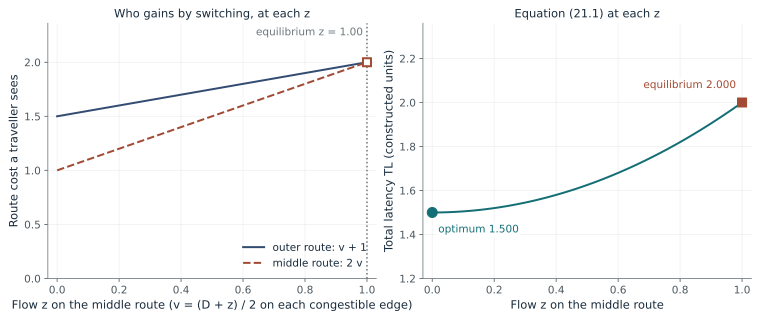

In [8]:
demo_id = 'C21-D01'
demo_controls = {'demand': 1, 'network': 'link'}
demo_result = run_demo(21, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Demand (units of traffic from S to T)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A free link: better, worse or unchanged
Controls: {"demand": 0.5, "network": "link"}
Evidence: constructed teaching example

Calculated quantities:
Total latency before the link: 0.625
Total latency, link added (equilibrium): 0.500
Total latency, social optimum: 0.500
Latency of each trip with the link: 1.000
Flow on the middle link: all travellers
Equilibrium over optimum: 1.000

Worked steps:
1. Demand D = 0.50. With z on the middle route, each congestible edge carries v = (D + z) / 2.
2. At z = 0: outer route 0.50 / 2 + 1 = 1.25; middle route 0.50 + 0 = 0.50.
3. Equilibrium z = 0.50, so v = (0.50 + 0.50) / 2 = 0.50.
4. Seen costs at equilibrium: outer 0.50 + 1 = 1.50, middle 2 x 0.50 = 1.00.
5. Total latency at equilibrium = 2 x 0.50 x 0.50 + 2 x 0.00 x 1.00 = 0.50 + 0.00 = 0.50.
6. Social optimum: z = 0.50, total latency 0.500.
7. Ratio = 0.500 / 0.500 = 1.000.

At z = 0 an outer route costs 0.50 / 2 + 1 = 1.25 and the middle route costs 0.50 + 0 = 0.50, so travellers switch to the

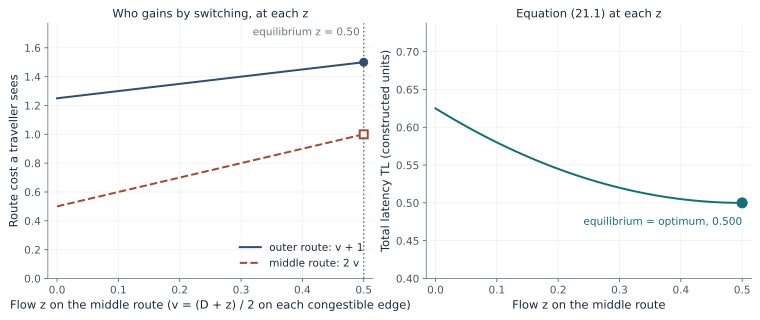

In [9]:
changed_controls = {'demand': 0.5, 'network': 'link'}
changed_demo = run_demo(21, 'C21-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(21, 'C21-D01'):
    state = run_demo(21, 'C21-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "demand": 0.5,
      "network": "link"
    },
    "metrics": [
      [
        "Total latency before the link",
        "0.625"
      ],
      [
        "Total latency, link added (equilibrium)",
        "0.500"
      ],
      [
        "Total latency, social optimum",
        "0.500"
      ],
      [
        "Latency of each trip with the link",
        "1.000"
      ],
      [
        "Flow on the middle link",
        "all travellers"
      ],
      [
        "Equilibrium over optimum",
        "1.000"
      ]
    ]
  },
  {
    "controls": {
      "demand": 0.5,
      "network": "nolink"
    },
    "metrics": [
      [
        "Total latency, link removed (equilibrium)",
        "0.625"
      ],
      [
        "Split on the upper route",
        "0.25 of 0.50 units"
      ],
      [
        "Latency of each trip",
        "1.250"
      ],
      [
        "Total latency, social optimum",
        "0.625"
      ],
      [
        "Equilibrium over optimu

**Check your understanding:** At demand 1.5, what does each trip cost with the link, and how does that compare with the cost of an outer route?

[Answer and worked reasoning](../solutions/ch21.md#demonstration-1). [Matching browser demonstration](../readers/21-congestion-incentives/reader.html#C21-D01).

<a id="demo-c21-d02"></a>

### Demonstration 2: How bad can it get with linear delays

Across every demand, how large can the ratio of equilibrium delay to optimal delay be when every delay is linear, and where does the gap come from?

![Equation 21.2](../assets/math/c707158415fb2c2d45b6.svg)

**Symbols and units:** S is the source, T the target, U the upper junction and L the lower junction. The three routes are S-U-T, S-L-T and S-U-L-T, which crosses the directed middle link from U to L. TL(q) is total latency. q^NE is the equilibrium flow and q* the flow with the smallest total latency, so the ratio compares self-directed routing with the best feasible routing. Linear means each edge delay is a times its flow plus b, with a and b not negative. The control sets a constant delay on the middle link (the b of that edge); 0 is the chapter's free link. In the right panel, the flow on the middle link is shown for the equilibrium and for the optimum at each demand.

Each point of the left curve is the lab's equilibrium total divided by its optimal total at one demand. The ratio is 1 when the link is unused or already optimal. The right panel shows why it rises: it peaks where demand is just large enough that the optimum shuts the link while the equilibrium still crowds onto it (the hatched gap). With a free link the peak reaches 4/3 exactly, and no linear delay example can go higher. The chapter's strings-and-springs image states the same bound as a distance: after severing, the weight hangs at least 1 / (4 / 3) = 0.75 of its original distance below the support.

**Use in this chapter:** When someone quotes a worst-case ratio for a queue or workflow, first check that its delays really are linear over the range of load the team will see. A ratio proved for one class of delay says nothing outside that class.

**Assumptions:** The same one-unit network with the middle link given a constant delay. The bound applies because every delay stays linear. The chapter notes that if delays are only continuous and nondecreasing, the ratio can be unbounded; thresholds, retry storms and sudden queue growth may not have the linear form, in which case the 4/3 figure is not guaranteed.

**Predict before running:** Make the link slower (delay 0.5). Does the highest ratio rise, fall or stay at 4/3?

**Controls you can change:**

- **Constant delay on the middle link:** `overhead` accepts 0, 0.25, 0.5, 1.

**Source section:** What linear bound says, and what it does not.

**Evidence:** constructed teaching example.

Constructed example: the chapter's network with a middle-link delay defined for this reader; ratios and flows are computed with the laboratory's congestion function.

Prediction choices:

1. Rise above 4/3
2. Stay at 4/3
3. Fall below 4/3

**Boundary of the conclusion:** The linear four-thirds bound does not cover every queue or institution. Check the latency-function class before applying the ratio: a linear approximation over ordinary load does not establish a guarantee past that operating range.

**Common wrong turn:** The chapter says treating four thirds as a generic comfort number would repeat the opening error, substituting a convenient measurement for the object being measured. Under only continuous, nondecreasing latency functions the ratio can be unbounded, so the bound belongs to a declared model of delay, not to the word equilibrium.

How bad can it get with linear delays
Controls: {"overhead": 0}
Evidence: constructed teaching example

Calculated quantities:
Largest ratio on the grid: 1.333
Demand at the largest ratio: 1.00
Bound from Equation (21.2): 1.333
Room below the bound: 0.000

Worked steps:
1. A link trip costs 2v + 0.00 against v + 1 on an outer route, where v is the flow on a congestible edge.
2. The ratio peaks where the optimum has just shut the link but the equilibrium still crowds onto it: m = 1 - 0.00 = 1.00.
3. Equilibrium total at m: 1.00 x (2 x 1.00 + 0.00) = 2.000.
4. Optimal total at m: 1.00 x (1.00 / 2 + 1) = 1.500.
5. Ratio = 2.000 / 1.500 = 1.333.
6. Room below the bound = 4 / 3 - 1.3333 = 0.000 (the ratio carried to four decimals).

Peak at demand m = 1 - 0.00 = 1.00. Everyone on the link: each trip costs 2 x 1.00 + 0.00 = 2.00, total 1.00 x 2.00 = 2.000. Optimum, nobody on the link: each trip costs 1.00 / 2 + 1 = 1.500, total 1.00 x 1.500 = 1.500. Ratio = 2.000 / 1.500 = 1.333. This reache

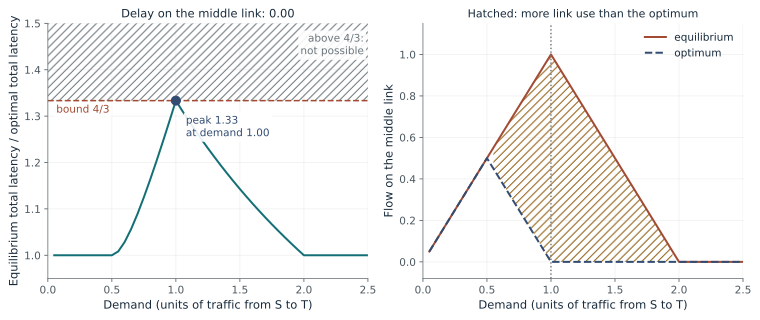

In [11]:
demo_id = 'C21-D02'
demo_controls = {'overhead': 0}
demo_result = run_demo(21, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Constant delay on the middle link** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

How bad can it get with linear delays
Controls: {"overhead": 0.25}
Evidence: constructed teaching example

Calculated quantities:
Largest ratio on the grid: 1.273
Demand at the largest ratio: 0.75
Bound from Equation (21.2): 1.333
Room below the bound: 0.061

Worked steps:
1. A link trip costs 2v + 0.25 against v + 1 on an outer route, where v is the flow on a congestible edge.
2. The ratio peaks where the optimum has just shut the link but the equilibrium still crowds onto it: m = 1 - 0.25 = 0.75.
3. Equilibrium total at m: 0.75 x (2 x 0.75 + 0.25) = 1.3125.
4. Optimal total at m: 0.75 x (0.75 / 2 + 1) = 1.03125.
5. Ratio = 1.3125 / 1.03125 = 1.273.
6. Room below the bound = 4 / 3 - 1.2727 = 0.061 (the ratio carried to four decimals).

Peak at demand m = 1 - 0.25 = 0.75. Everyone on the link: each trip costs 2 x 0.75 + 0.25 = 1.75, total 0.75 x 1.75 = 1.3125. Optimum, nobody on the link: each trip costs 0.75 / 2 + 1 = 1.375, total 0.75 x 1.375 = 1.03125. Ratio = 1.3125 / 1.03125 = 1.2

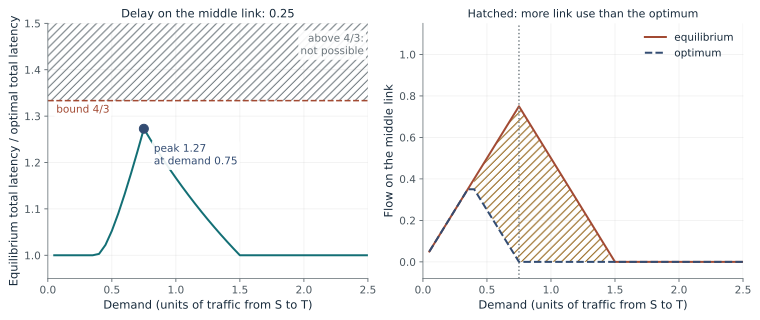

In [12]:
changed_controls = {'overhead': 0.25}
changed_demo = run_demo(21, 'C21-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(21, 'C21-D02'):
    state = run_demo(21, 'C21-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "overhead": 0
    },
    "metrics": [
      [
        "Largest ratio on the grid",
        "1.333"
      ],
      [
        "Demand at the largest ratio",
        "1.00"
      ],
      [
        "Bound from Equation (21.2)",
        "1.333"
      ],
      [
        "Room below the bound",
        "0.000"
      ]
    ]
  },
  {
    "controls": {
      "overhead": 0.25
    },
    "metrics": [
      [
        "Largest ratio on the grid",
        "1.273"
      ],
      [
        "Demand at the largest ratio",
        "0.75"
      ],
      [
        "Bound from Equation (21.2)",
        "1.333"
      ],
      [
        "Room below the bound",
        "0.061"
      ]
    ]
  },
  {
    "controls": {
      "overhead": 0.5
    },
    "metrics": [
      [
        "Largest ratio on the grid",
        "1.200"
      ],
      [
        "Demand at the largest ratio",
        "0.50"
      ],
      [
        "Bound from Equation (21.2)",
        "1.333"
      ],
      [
 

**Check your understanding:** With a delay of 0.25 on the middle link, what is the highest ratio?

[Answer and worked reasoning](../solutions/ch21.md#demonstration-2). [Matching browser demonstration](../readers/21-congestion-incentives/reader.html#C21-D02).

<a id="demo-c21-d03"></a>

### Demonstration 3: Charging for the delay you export

If every congestible edge charges its own delay plus the delay the traveller adds for others, where does the equilibrium land, and how does a toll on the link alone compare?

![Equation 21.3](../assets/math/0d9a15c23069ca305b11.svg)

**Symbols and units:** S is the source, T the target, U the upper junction and L the lower junction. The three routes are S-U-T, S-L-T and S-U-L-T, which crosses the directed middle link from U to L. l_e(q_e) is the delay on edge e at flow q_e. The marginal-cost latency adds q_e times the slope of l_e, which is the extra delay one more unit of flow imposes on those already there. For a delay a x q + b the charged cost is 2 x a x q + b: the congestion term doubles and the fixed term does not. Here a = 1 and b = 0 on a congestible edge, and a = 0 and b = 1 on a fixed edge. A toll on the link alone adds a fixed charge to the middle route only; it is a different rule from the marginal-cost charge.

Travellers still choose the cheapest route, but now by the charged cost. The charge turns the old comparison 1 + v against 2v into 2v + 1 against 4v, which moves traffic back toward the outer routes. The physical delay then equals the best possible total. A toll of 0.5 on the link alone is the notebook's variant: a different rule, although at the demands shown it gives the same flows and the same total as the marginal-cost charge. At demand 1 the smallest toll that empties the link is 0.5, and 0.49 leaves 0.02 of the traffic on it. At demand 0.5, the notebook's transfer case, the link is privately efficient, so the paradox depends on the demand regime.

**Use in this chapter:** In a shared workflow, the charge might be a rising budget for a busy shared tool, a queue-aware scheduler or a concurrency limit. The common property is that a local choice receives a signal about the shared resource it uses.

**Assumptions:** Linear delays, a total-delay objective, and a charge that is paid but not counted as physical delay. A real signal can be late, noisy, gameable or attached to the wrong boundary, and the objective may omit fairness or safety. The chapter treats the construction as proof that one gap can be closed under stated conditions, not as a general policy answer.

**Predict before running:** At demand 1 with the marginal-cost charge, how much traffic uses the middle link?

**Controls you can change:**

- **Charging rule:** `rule` accepts 'none', 'marginal', 'toll', 'toll49'.
- **Demand (units of traffic from S to T):** `demand` accepts 1, 0.75, 0.5.

**Source section:** Prices that make group target locally legible.

**Evidence:** constructed teaching example.

Constructed example: the chapter's network and its marginal-cost charge at the laboratory's default demand 1, a changed toll and the transfer demand 0.5; the no-charge and toll cases use the laboratory's congestion function, and the marginal-cost flows are derived here and checked against the laboratory's optimum.

Prediction choices:

1. All of it (1.00)
2. Half of it (0.50)
3. None (0.00)

**Boundary of the conclusion:** Marginal-cost pricing does not decide fairness, authority, or legitimacy. Those require objectives and constraints stated outside the routing model.

**Common wrong turn:** The notebook's toll of 0.5 on the shortcut alone is a different rule from the chapter's marginal-cost charge of 0.5 on each congestible edge (Equation (21.3)). The chapter keeps the charge out of physical travel time: payments are transfers, and adding them to travel time would change the objective being minimized.

Charging for the delay you export
Controls: {"rule": "marginal", "demand": 1}
Evidence: constructed teaching example

Calculated quantities:
Rule: Marginal-cost charge
Outer route cost seen: 2.00
Middle route cost seen: 2.00
Flow on the middle route: 0.00
Physical total latency: 1.5000
Social optimum: 1.5000

Worked steps:
1. Rule: marginal-cost charge; demand D = 1.00.
2. Travellers pick the cheapest seen route: 0.50 on each outer route and 0.00 on the middle.
3. Each congestible edge carries v = 0.50 + 0.00 = 0.50.
4. Corrected cost of an outer route = 2 x 0.50 + 1 = 2.00; of the middle route = 2 x 0.50 + 2 x 0.50 = 2.00.
5. Physical total = 2 x 0.50 x 0.50 + 2 x 0.50 x 1.00 = 1.5000.
6. Social optimum = 1.5000; excess = 1.5000 - 1.5000 = 0.0000.

At demand 1.00 the equilibrium puts 0.50 on each outer route and 0.00 on the middle, so each congestible edge carries 0.50. Corrected cost of an outer route = 2 x 0.50 + 1 = 2.00; of the middle route = 2 x 0.50 + 2 x 0.50 = 2.00. Physical t

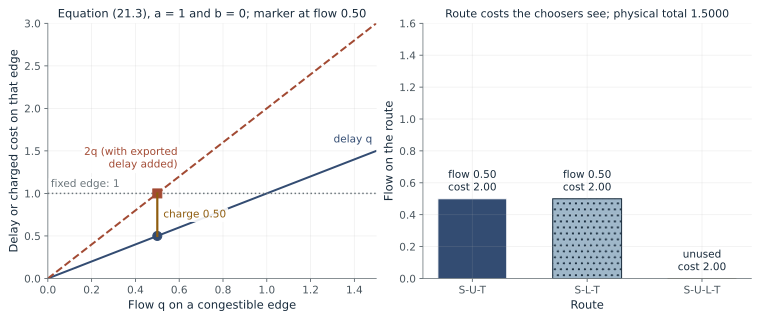

In [14]:
demo_id = 'C21-D03'
demo_controls = {'rule': 'marginal', 'demand': 1}
demo_result = run_demo(21, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Charging rule** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Charging for the delay you export
Controls: {"rule": "none", "demand": 1}
Evidence: constructed teaching example

Calculated quantities:
Rule: No charge
Outer route cost seen: 2.00
Middle route cost seen: 2.00
Flow on the middle route: 1.00
Physical total latency: 2.0000
Social optimum: 1.5000

Worked steps:
1. Rule: no charge; demand D = 1.00.
2. Travellers pick the cheapest seen route: 0.00 on each outer route and 1.00 on the middle.
3. Each congestible edge carries v = 0.00 + 1.00 = 1.00.
4. Outer route = 1.00 + 1 = 2.00; middle route = 1.00 + 1.00 = 2.00.
5. Physical total = 2 x 1.00 x 1.00 + 2 x 0.00 x 1.00 = 2.0000.
6. Social optimum = 1.5000; excess = 2.0000 - 1.5000 = 0.5000.

At demand 1.00 the equilibrium puts 0.00 on each outer route and 1.00 on the middle, so each congestible edge carries 1.00. Outer route = 1.00 + 1 = 2.00; middle route = 1.00 + 1.00 = 2.00. Physical total = 2 x 1.00 x 1.00 + 2 x 0.00 x 1.00 = 2.0000. Physical total latency 2.0000 is 0.5000 above the socia

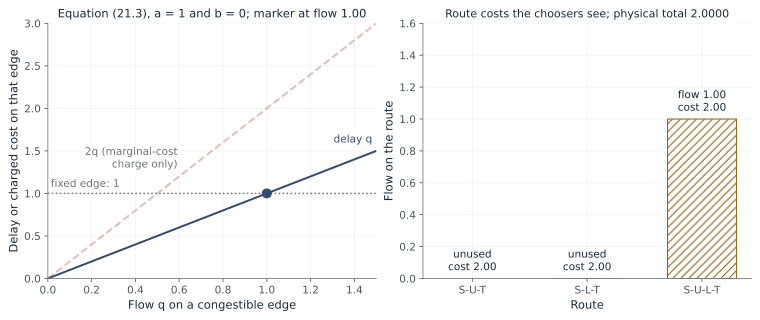

In [15]:
changed_controls = {'rule': 'none', 'demand': 1}
changed_demo = run_demo(21, 'C21-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(21, 'C21-D03'):
    state = run_demo(21, 'C21-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "rule": "none",
      "demand": 1
    },
    "metrics": [
      [
        "Rule",
        "No charge"
      ],
      [
        "Outer route cost seen",
        "2.00"
      ],
      [
        "Middle route cost seen",
        "2.00"
      ],
      [
        "Flow on the middle route",
        "1.00"
      ],
      [
        "Physical total latency",
        "2.0000"
      ],
      [
        "Social optimum",
        "1.5000"
      ]
    ]
  },
  {
    "controls": {
      "rule": "none",
      "demand": 0.75
    },
    "metrics": [
      [
        "Rule",
        "No charge"
      ],
      [
        "Outer route cost seen",
        "1.75"
      ],
      [
        "Middle route cost seen",
        "1.50"
      ],
      [
        "Flow on the middle route",
        "0.75"
      ],
      [
        "Physical total latency",
        "1.1250"
      ],
      [
        "Social optimum",
        "1.0000"
      ]
    ]
  },
  {
    "controls": {
      "rule": "none",

**Check your understanding:** At demand 0.75 with the marginal-cost charge, what flow goes on the middle link?

[Answer and worked reasoning](../solutions/ch21.md#demonstration-3). [Matching browser demonstration](../readers/21-congestion-incentives/reader.html#C21-D03).

<a id="demo-c21-d04"></a>

### Demonstration 4: Capacity is a comparison, not a cure

How does the cost of selfish routing at rate r compare with the best routing that must carry extra traffic?

![Mathematical relation](../assets/demo-equations/4099b4f88144d3c4b54b.svg)

![Mathematical relation](../assets/demo-equations/58237163f1ec833aa207.svg)

**Symbols and units:** r is the traffic rate and gamma_cap (written extra here) is a positive fraction. The first expression, (1 + gamma_cap) r, is the traffic the benchmark carries: an optimal flow that carries (1 + extra) times r. The second, 1 / gamma_cap, is the guaranteed factor. The theorem combines them: equilibrium cost at r is at most 1 / extra times the benchmark's cost at (1 + extra) r. The cost is total latency, as in Equation (21.1). Nobody adds a road: the network stays the same and only the benchmark's burden changes.

Left panel: the optimal cost grows with the traffic it must carry, so asking the benchmark to carry more makes the comparison easier for the equilibrium. Right panel: the guaranteed factor 1 / extra falls from 4 to 1 as extra grows from 0.25 to 1, while this particular network stays near or under 1. The theorem is a worst-case promise and does not tell you which server to buy.

**Use in this chapter:** In a staffing meeting, separate delay caused by too little throughput from delay caused by a rule that steers work into one stage. More capacity can lower delay at a given flow, but it can also make a stage attractive to more work and shift the equilibrium again.

**Assumptions:** The chapter's linear network and the rates r = 0.5, 0.75 and 1. The guarantee is a bound over all networks in its class, and this network does not come close to it, so the picture shows the comparison, not tightness. It says nothing about adding capacity to a real system, where demand responds.

**Predict before running:** With extra = 1 (the benchmark carries twice the traffic) at r = 1, is the equilibrium cost below or above the optimal cost at rate 2?

**Controls you can change:**

- **Traffic rate r:** `rate` accepts 0.5, 0.75, 1.
- **Extra-traffic fraction:** `extra` accepts 0.25, 0.5, 1.

**Source section:** Capacity is a comparison, not a cure.

**Evidence:** constructed teaching example.

Constructed example: the chapter's network at rates defined for this reader; all costs are computed with the laboratory's congestion function.

Prediction choices:

1. Below it
2. Above it

**Boundary of the conclusion:** The bicriteria comparison says how much worse a self-directed allocation can be relative to a deliberately burdened benchmark. It does not identify which server to buy.

**Common wrong turn:** The chapter says the phrase 'forced to carry twice the traffic' is the whole statement: it does not mean that capacity was doubled. The network is unchanged and the comparison changes the amount of demand the optimal benchmark must serve.

Capacity is a comparison, not a cure
Controls: {"rate": 1, "extra": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Equilibrium cost at r: 2.000
Optimal cost at (1 + extra) r: 2.625
Equilibrium over optimum: 0.762
Guaranteed factor 1/extra: 2.00
Within the guarantee: yes

Worked steps:
1. Equilibrium at r = 1.00: everyone takes the link, so each congestible edge carries 1.00.
2. Equilibrium cost = 2 x 1.00 x 1.00 = 2.000.
3. The benchmark must carry (1 + 0.50) x 1.00 = 1.500.
4. Its optimal cost: 1.500 x (1.500 / 2 + 1) = 2.625.
5. Ratio = 2.000 / 2.625 = 0.762; guaranteed factor 1 / 0.50 = 2.00.

Equilibrium at r = 1.00: 2 x 1.00 x 1.00 = 2.000 (all traffic takes the link, each congestible edge carries 1.00). The optimum must carry (1 + 0.50) x 1.00 = 1.500: 1.500 x (1.500 / 2 + 1) = 2.625. Ratio = 2.000 / 2.625 = 0.762, against the guaranteed factor 1 / 0.50 = 2.00. This network sits far under the guarantee, which is a worst case over all networks, not a forecast.

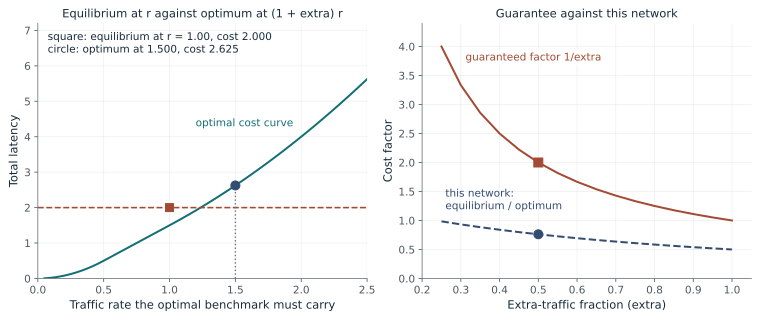

In [17]:
demo_id = 'C21-D04'
demo_controls = {'rate': 1, 'extra': 0.5}
demo_result = run_demo(21, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Traffic rate r** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Capacity is a comparison, not a cure
Controls: {"rate": 0.5, "extra": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Equilibrium cost at r: 0.500
Optimal cost at (1 + extra) r: 1.000
Equilibrium over optimum: 0.500
Guaranteed factor 1/extra: 2.00
Within the guarantee: yes

Worked steps:
1. Equilibrium at r = 0.50: everyone takes the link, so each congestible edge carries 0.50.
2. Equilibrium cost = 2 x 0.50 x 0.50 = 0.500.
3. The benchmark must carry (1 + 0.50) x 0.50 = 0.750.
4. Its optimal cost: 2 x 0.750 - 0.5 = 1.000.
5. Ratio = 0.500 / 1.000 = 0.500; guaranteed factor 1 / 0.50 = 2.00.

Equilibrium at r = 0.50: 2 x 0.50 x 0.50 = 0.500 (all traffic takes the link, each congestible edge carries 0.50). The optimum must carry (1 + 0.50) x 0.50 = 0.750: 2 x 0.750 - 0.5 = 1.000. Ratio = 0.500 / 1.000 = 0.500, against the guaranteed factor 1 / 0.50 = 2.00. This network sits far under the guarantee, which is a worst case over all networks, not a forecast. The benchmark

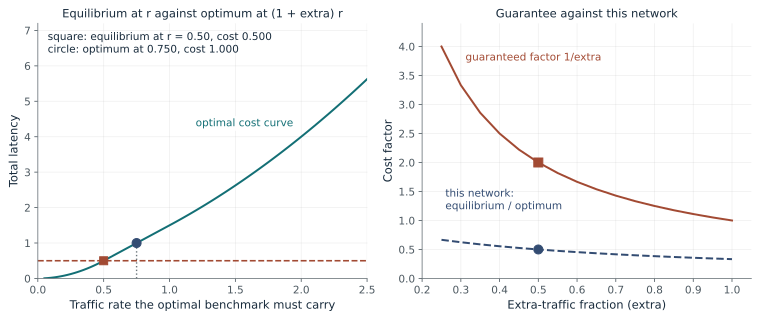

In [18]:
changed_controls = {'rate': 0.5, 'extra': 0.5}
changed_demo = run_demo(21, 'C21-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(21, 'C21-D04'):
    state = run_demo(21, 'C21-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "rate": 0.5,
      "extra": 0.25
    },
    "metrics": [
      [
        "Equilibrium cost at r",
        "0.500"
      ],
      [
        "Optimal cost at (1 + extra) r",
        "0.750"
      ],
      [
        "Equilibrium over optimum",
        "0.667"
      ],
      [
        "Guaranteed factor 1/extra",
        "4.00"
      ],
      [
        "Within the guarantee",
        "yes"
      ]
    ]
  },
  {
    "controls": {
      "rate": 0.5,
      "extra": 0.5
    },
    "metrics": [
      [
        "Equilibrium cost at r",
        "0.500"
      ],
      [
        "Optimal cost at (1 + extra) r",
        "1.000"
      ],
      [
        "Equilibrium over optimum",
        "0.500"
      ],
      [
        "Guaranteed factor 1/extra",
        "2.00"
      ],
      [
        "Within the guarantee",
        "yes"
      ]
    ]
  },
  {
    "controls": {
      "rate": 0.5,
      "extra": 1
    },
    "metrics": [
      [
        "Equilibrium cost at r",
    

**Check your understanding:** With r = 1 and extra = 0.5, what must the benchmark carry, and what is its cost?

[Answer and worked reasoning](../solutions/ch21.md#demonstration-4). [Matching browser demonstration](../readers/21-congestion-incentives/reader.html#C21-D04).

## Questions

1. Compute default price of anarchy.

2. Why exclude toll revenue from social travel time?

3. Compute transfer social optimum.

Answers: [separate solutions](../solutions/ch21.md). Try the calculation before opening them.

## Summary

Local incentives and collective outcomes can diverge. The Braess construction makes that divergence exact: a shortcut worsens default equilibrium, a toll restores efficient routing, and low-demand transfer removes the paradox. The notebook distinguishes physical overhead from private incentive charges and compares equilibrium with a convex social optimum. Its conclusions depend on the supplied network form, continuous flow, and cost law. It does not infer how a real team will respond.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-21-congestion-incentives`](../skills/maa-21-congestion-incentives/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 21.1

![Equation 21.1](../assets/math/789a238d6278b03f32dc.svg)

Equation (21.1) adds each edge's delay across all flow using that edge, producing the system's total time.

Multiply traffic on every edge by its experienced latency, then add the products over the whole network.

LaTeX source, preserved for inspection:

```latex
\operatorname{TL}(q) \;=\; \sum_{e\in\mathcal E} q_e\,\ell_e(q_e).
\tag{21.1}
```

### Equation 21.2

![Equation 21.2](../assets/math/c707158415fb2c2d45b6.svg)

Equation (21.2) bounds self-directed routing's total delay against best feasible routing when every edge delay is linear.

Divide equilibrium delay by optimal delay; under nonnegative straight-line latency rules, ratio never exceeds four thirds.

LaTeX source, preserved for inspection:

```latex
\frac{\operatorname{TL}(q^{\mathrm{NE}})}{\operatorname{TL}(q^{\star})} \;\leq\; \frac{4}{3}
\qquad\text{when every }\ell_e(q_e)=a_e q_e+b_e\text{ with }a_e,b_e\geq0.
\tag{21.2}
```

### Equation 21.3

![Equation 21.3](../assets/math/0d9a15c23069ca305b11.svg)

Equation (21.3) converts an edge's experienced delay into a local price that includes congestion imposed on existing users.

Add the direct delay to flow times its slope; for straight-line delay, double only the congestion term.

LaTeX source, preserved for inspection:

```latex
\ell^{\mathrm{mc}}_e(q_e) \;=\; \ell_e(q_e)+q_e\ell'_e(q_e),
\qquad
\ell_e(q_e)=a_e q_e+b_e\;\Longrightarrow\;\ell^{\mathrm{mc}}_e(q_e)=2a_e q_e+b_e.
\tag{21.3}
```